In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.decomposition import PCA

In [2]:
df = sns.load_dataset("penguins")


In [4]:
"Dataset Shape:", df.shape
df.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [6]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [7]:
df = df.dropna()

In [8]:
numeric_df = df.select_dtypes(include=['number'])

In [9]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)


In [10]:
Z = linkage(scaled_data, method='ward')


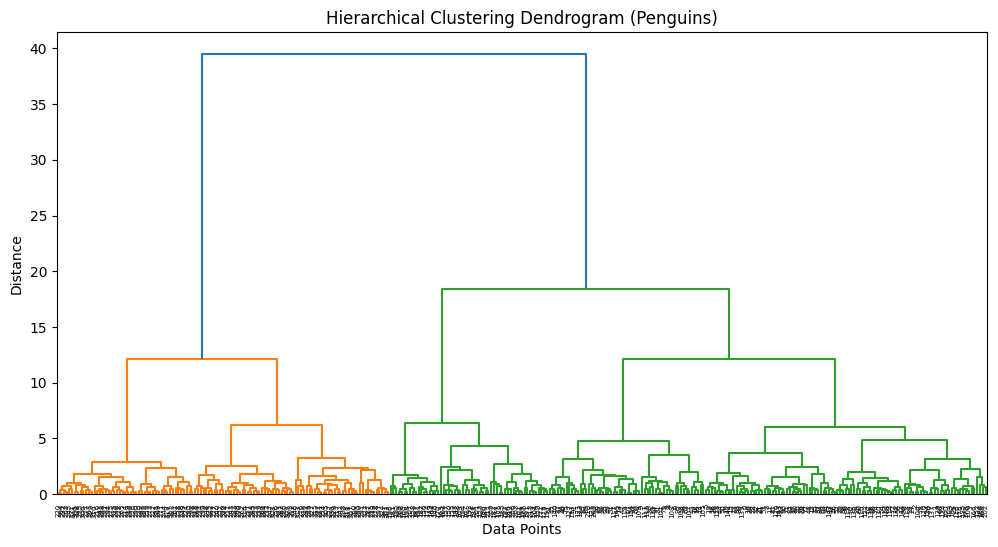

In [11]:
plt.figure(figsize=(12,6))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram (Penguins)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [12]:
clusters = fcluster(Z, t=3, criterion='maxclust')

In [13]:
df['Cluster'] = clusters

In [14]:
pca = PCA(n_components=2)
reduced = pca.fit_transform(scaled_data)


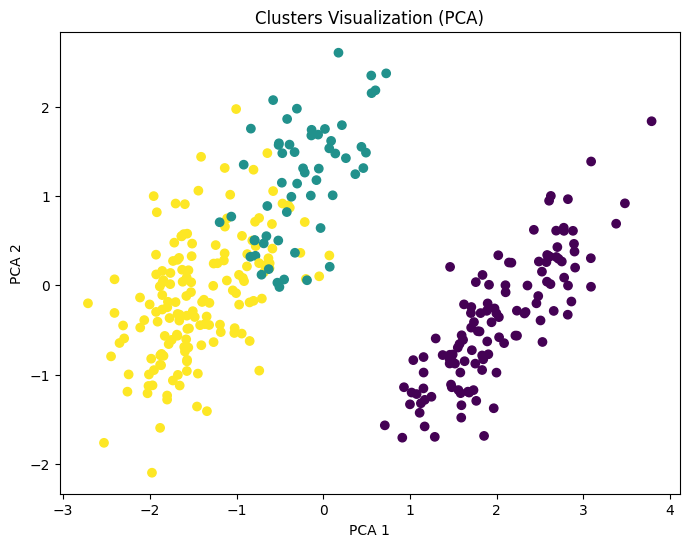

In [15]:
plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1], c=clusters)
plt.title("Clusters Visualization (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [16]:
from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_data, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.45209829496381126
